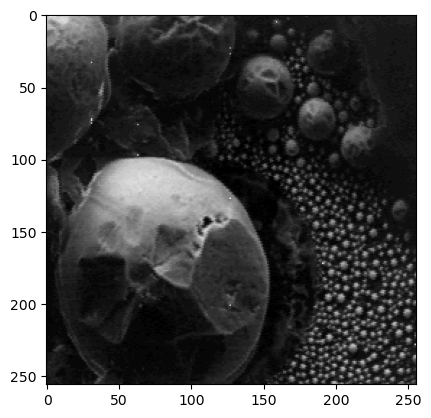

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

meb = cv2.imread('MEB.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(meb, cmap='gray')
plt.show()



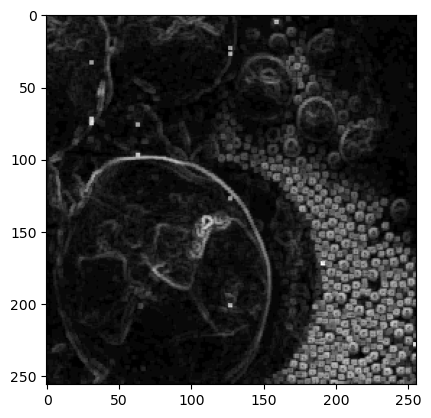

In [2]:
from scipy.ndimage import morphological_gradient


mascara3x3 = np.array([[1, 1, 1],
                        [1, 1, 1],
                        [1, 1, 1]]) / 9

mgimage = morphological_gradient(meb, footprint=mascara3x3)
plt.imshow(mgimage, cmap='gray')
plt.show()


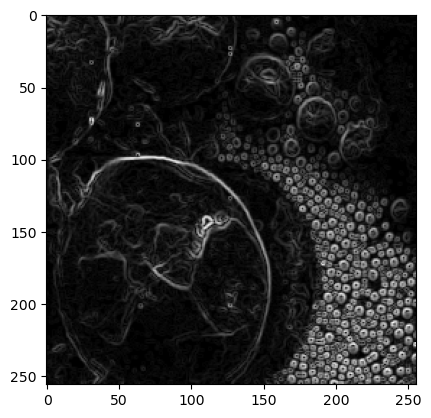

In [3]:

from skimage.filters import sobel


meb_s = sobel(meb)

plt.imshow(meb_s, cmap='gray')
plt.show()


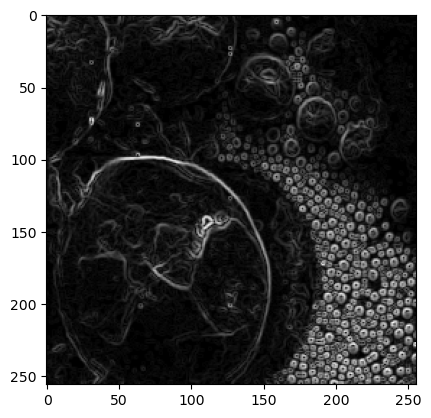

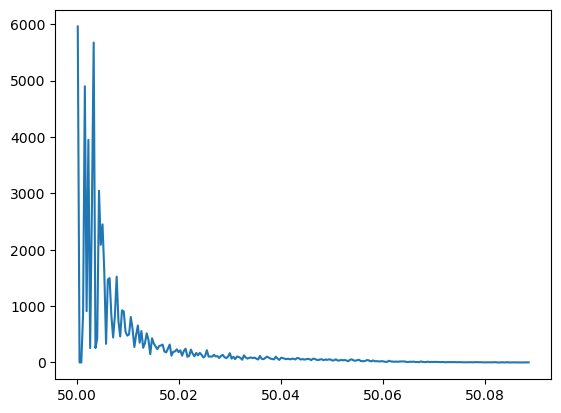

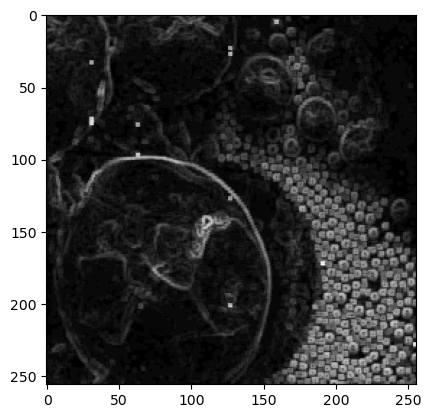

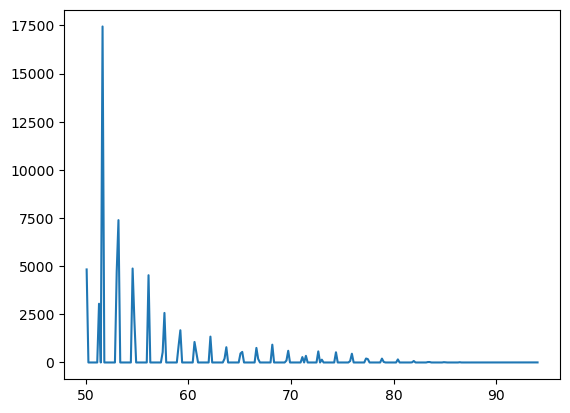

In [4]:
from skimage import exposure

meb_s_eq = exposure.rescale_intensity(meb_s, in_range=(0,255), out_range=(50,100))
plt.imshow(meb_s_eq, cmap='gray')
plt.show()

hist_s = exposure.histogram(meb_s_eq)
plt.plot(hist_s[1], hist_s[0])
plt.show()

mgimage_eq = exposure.rescale_intensity(mgimage, in_range=(0,255), out_range=(50,100))
plt.imshow(mgimage_eq, cmap='gray')
plt.show()

hist_mg = exposure.histogram(mgimage_eq)
plt.plot(hist_mg[1], hist_mg[0])
plt.show()

# gradiente morfológico vs. norma del gradiente
Se puede evidenciar que el sobel detecta cambios de intensidad menores lo que hace que sus picos sean más continuos, y que el resultado de la imagén esté más suavisado. Por otro lado, el gradiente morfológico detecta cambios menos intensos, lo cual puede ser útil para reducir el ruido. Esto se evidencia en picos más separados entre sí y de mayor tamaño. Esto puede ser útil también para detectar bordes más gruesos.

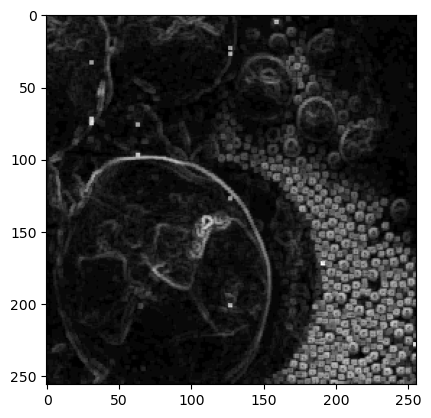

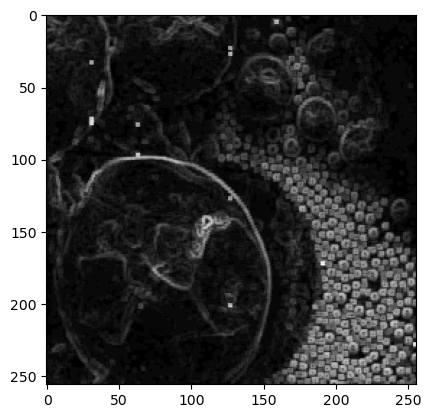

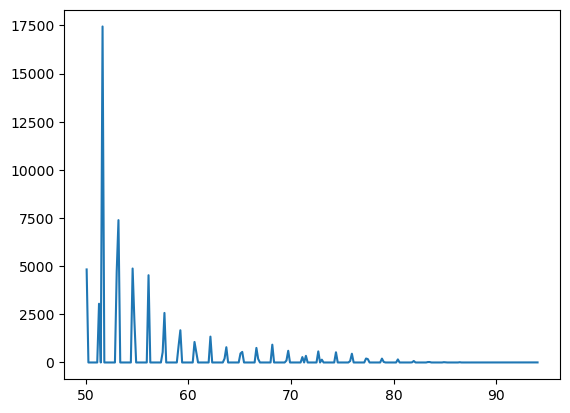

In [5]:

from skimage.morphology import dilation, erosion, opening, closing

eroded_manual = erosion(meb, footprint=mascara3x3)
dilated_manual = dilation(meb, footprint=mascara3x3)

gradient_manual = dilated_manual - eroded_manual

plt.imshow(gradient_manual, cmap='gray')
plt.show()


gradient_manual_eq = exposure.rescale_intensity(gradient_manual, in_range=(0,255), out_range=(50,100))
plt.imshow(gradient_manual_eq, cmap='gray')
plt.show()

hist_gm = exposure.histogram(gradient_manual_eq)
plt.plot(hist_gm[1], hist_gm[0])
plt.show()


# Resultados
El resultado obtenido igual al encontrado en el punto 3. Esto se puede evidenciar por el histograma y la imagen que son identicas a las encontradas anteriormente. Así, se puede concluir que para aplicar el gradiente morfológico de forma manual hay que aplicar una dilataciónn y restarle una erosión para conseguir una imagen donde se elimina el ruido y se encuentran principalmente los bordes gruesos.